In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
%matplotlib inline

In [25]:
df = pd.read_csv("Mobile_price.csv")

In [26]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [28]:
df.isna().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [29]:
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [30]:
df.shape

(2000, 21)

In [31]:
(df["px_height"]==0).sum()

np.int64(2)

In [32]:
df.drop(df[df["px_height"] == 0].index, inplace=True)

In [34]:
(df["px_height"]==0).sum()

np.int64(0)

In [36]:
(df["sc_w"]==0).sum()

np.int64(179)

In [37]:
df.drop(df[df["sc_w"] == 0].index, inplace=True)

In [38]:
(df["sc_w"]==0).sum()

np.int64(0)

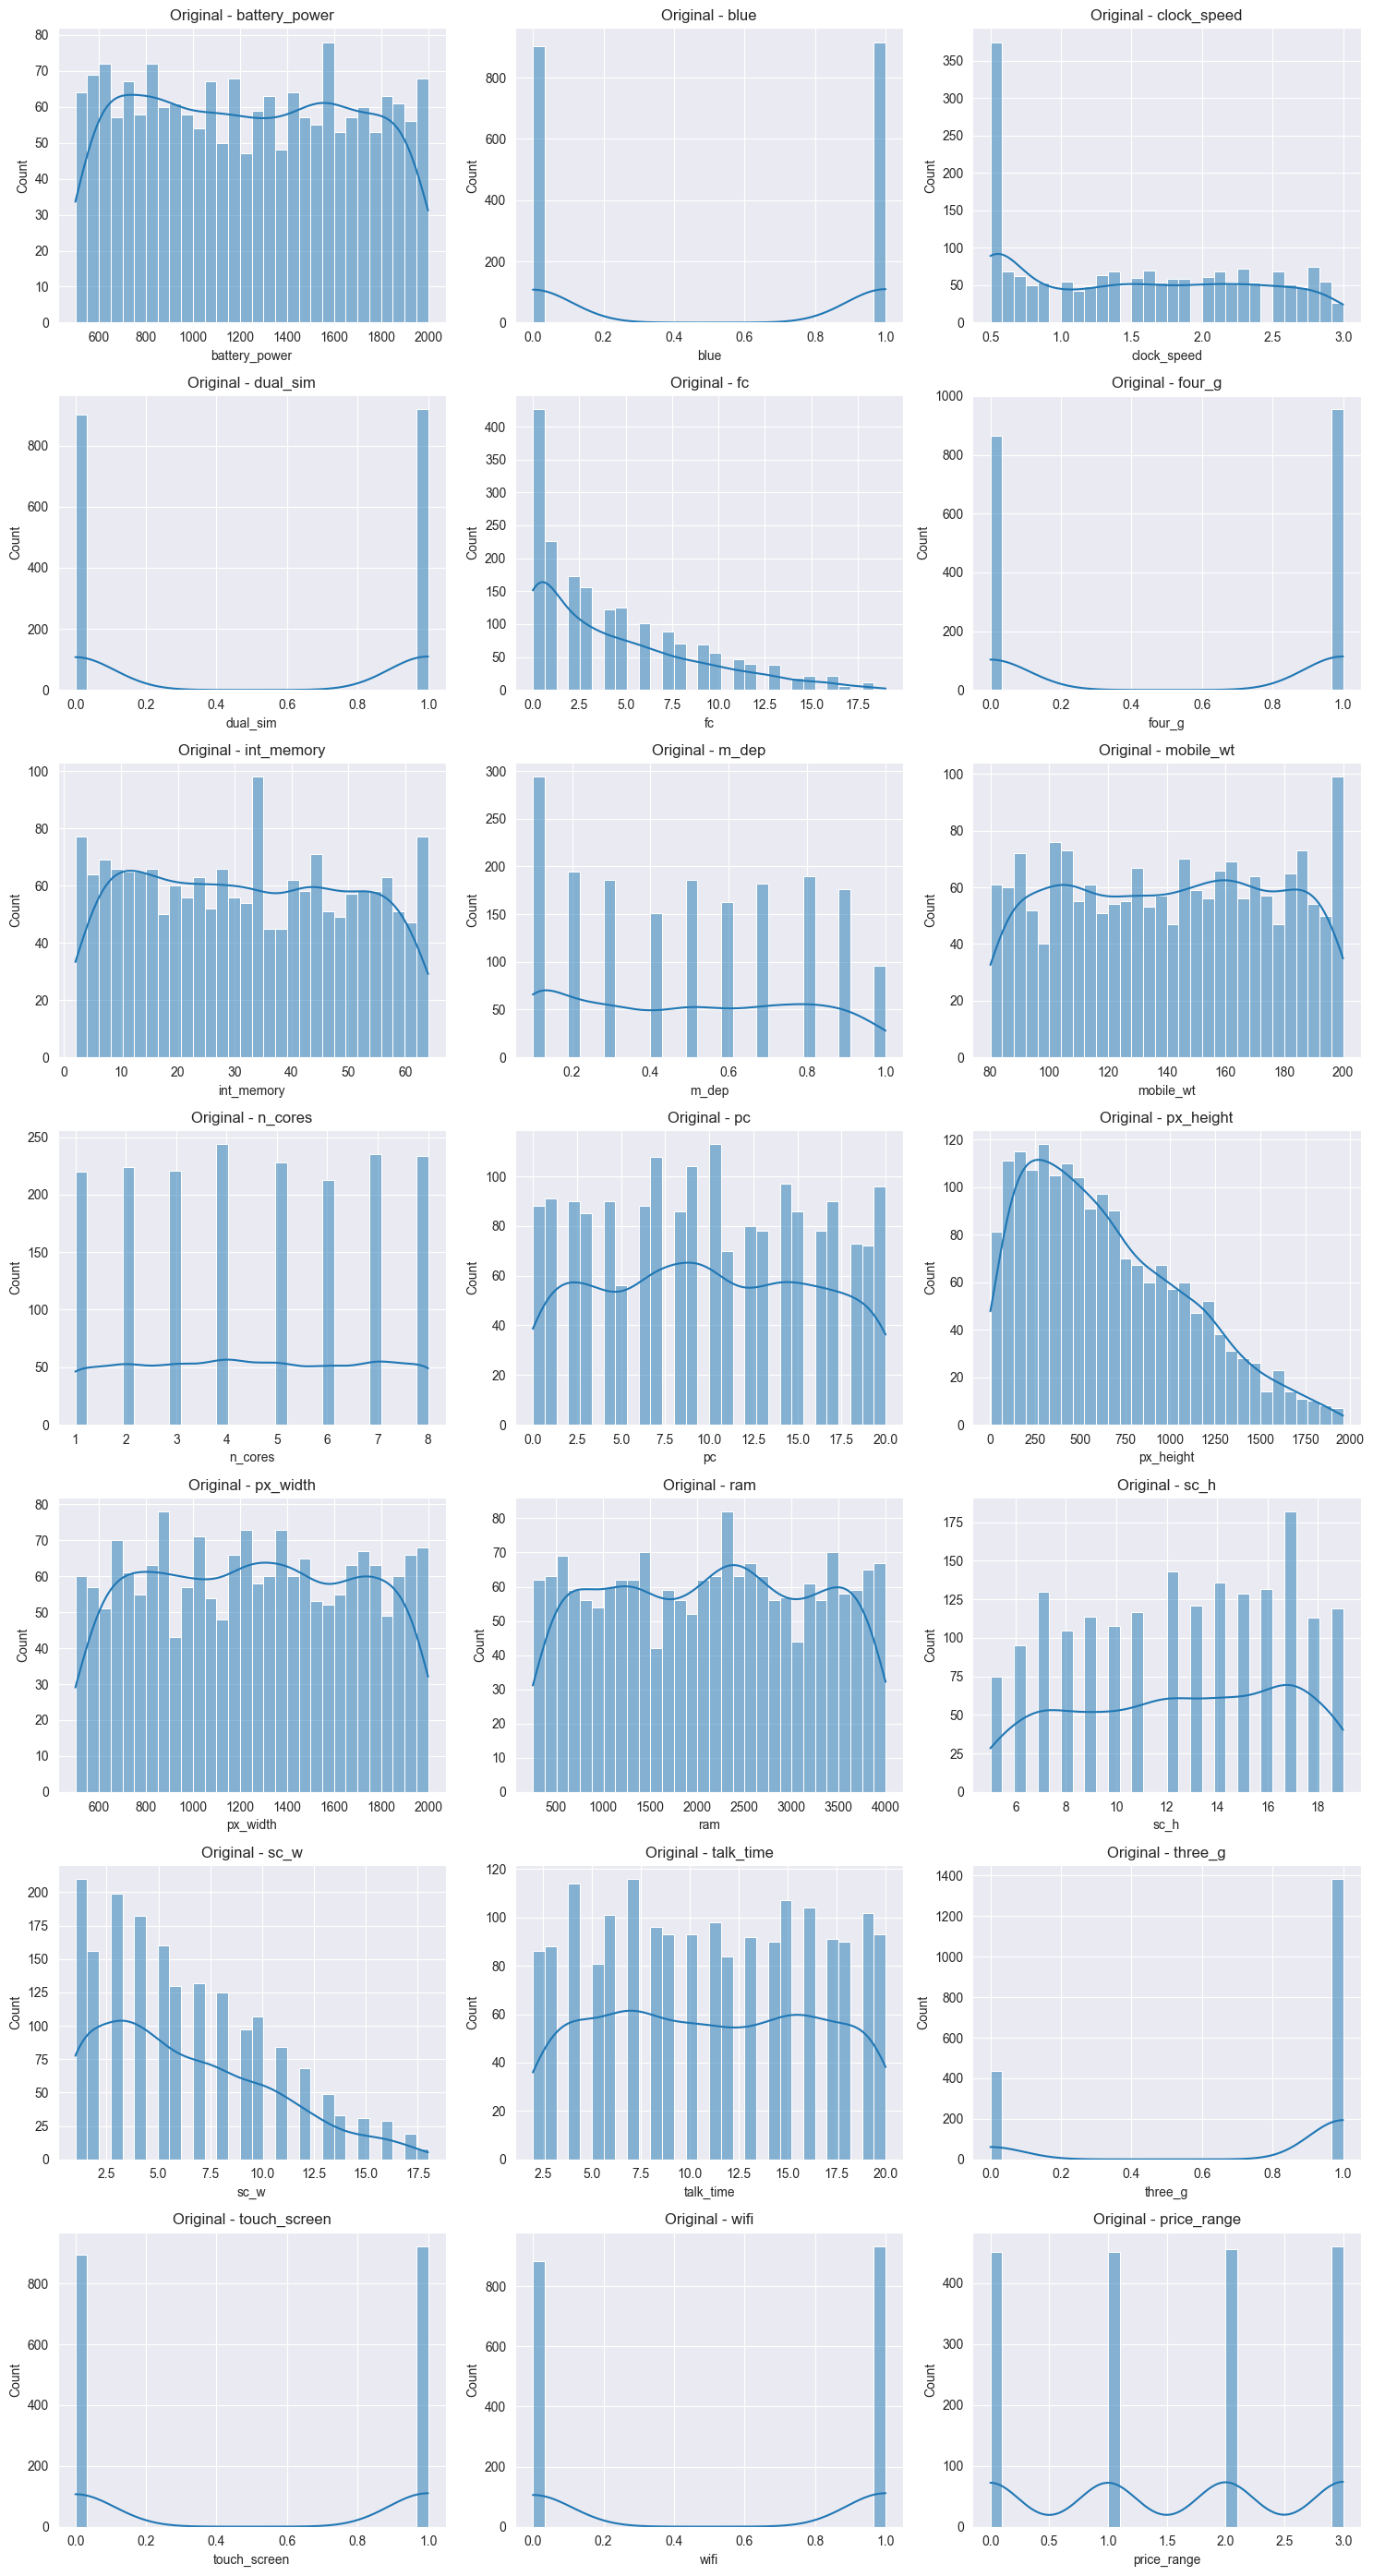

In [42]:
import math

def plot_all_histograms(df,title_prefix = ""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))
    for x, col in enumerate(num_cols,1):
        plt.subplot(n_rows, n_cols, x)
        sns.histplot(df[col], bins=30,kde=True)
        plt.title(f"{title_prefix}{col}" )

    plt.tight_layout()
    plt.show()

plot_all_histograms(df,title_prefix="Original - ")

<Axes: xlabel='pc', ylabel='fc'>

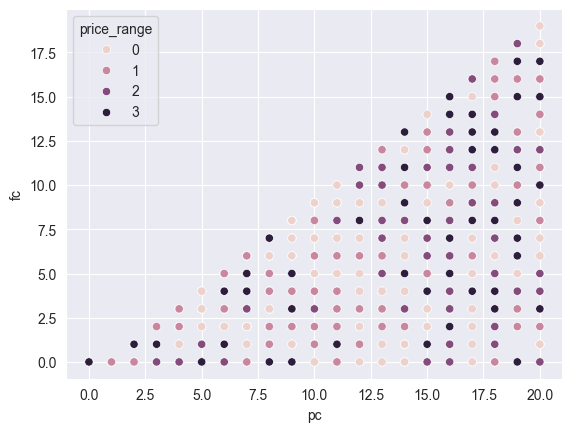

In [92]:
sns.scatterplot(data=df, x="pc", y="fc",hue="price_range")

<Axes: xlabel='ram', ylabel='price_range'>

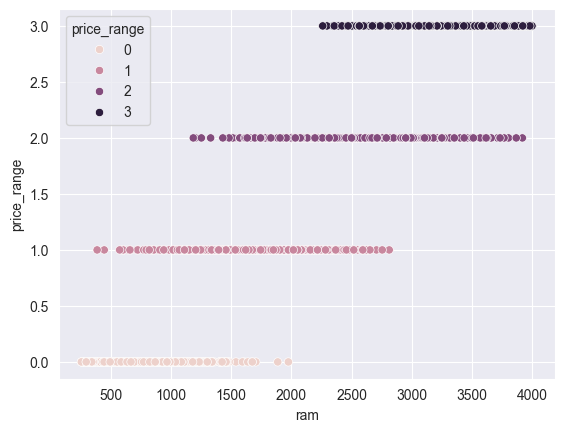

In [94]:
sns.scatterplot(data=df, x="ram", y="price_range",hue="price_range")

<Axes: xlabel='talk_time', ylabel='battery_power'>

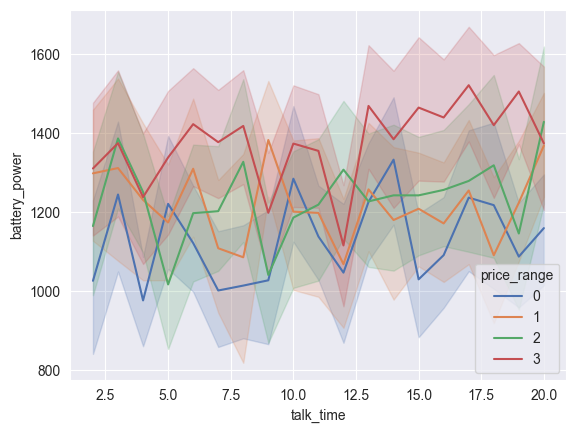

In [110]:
sns.lineplot(data=df, x="talk_time", y="battery_power",hue="price_range",palette="deep")

In [46]:
#outlier bulma fonksiyonu
def find_outliers_iqr(df, threshold):
    outlier_summary = {}
    numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
    print(numeric_cols)
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        iqr = Q3 - Q1

        lower_bound = Q1 - threshold * iqr
        upper_bound = Q3 + threshold * iqr

        outliers = df[ (df[col] < lower_bound) | (df[col] > upper_bound)]

        outlier_summary[col] = {
            "outlier_count": outliers.shape[0],
            "outlier_percentage": outliers.shape[0] / df.shape[0],
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
        }
    return pd.DataFrame(outlier_summary)


In [48]:
find_outliers_iqr(df,threshold=1.0)

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
outlier_count,0.0,0.0,0.0,0.0,79.00000,0.0,0.0,0.0,0.0,0.0,...,54.000000,0.0,0.0,0.0,56.000000,0.0,435.000000,0.0,0.0,0.0
outlier_percentage,0.0,0.0,0.0,0.0,0.04343,0.0,0.0,0.0,0.0,0.0,...,0.029687,0.0,0.0,0.0,0.030786,0.0,0.239142,0.0,0.0,0.0
lower_bound,79.0,-1.0,-0.8,-1.0,-5.00000,-1.0,-16.0,-0.4,47.5,-1.0,...,-384.000000,121.0,-665.5,2.0,-3.000000,-4.0,1.000000,-1.0,-1.0,-1.0
upper_bound,2377.0,2.0,3.7,2.0,13.00000,2.0,80.0,1.4,232.0,11.0,...,1620.000000,2389.0,4941.5,23.0,15.000000,26.0,1.000000,2.0,2.0,5.0


In [51]:
df.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

In [63]:
def show_boxplot(df):
    cols = 3                       # bir satırda 3 grafik
    n = len(df.columns)
    rows = math.ceil(n / cols)     # kaç satır olacağı

    plt.figure(figsize=(18, 5 * rows))

    for i, col in enumerate(df.columns, 1):
        plt.subplot(rows, cols, i)
        sns.boxplot(data=df, y=col)
        plt.title(col)

    plt.tight_layout()
    plt.show()


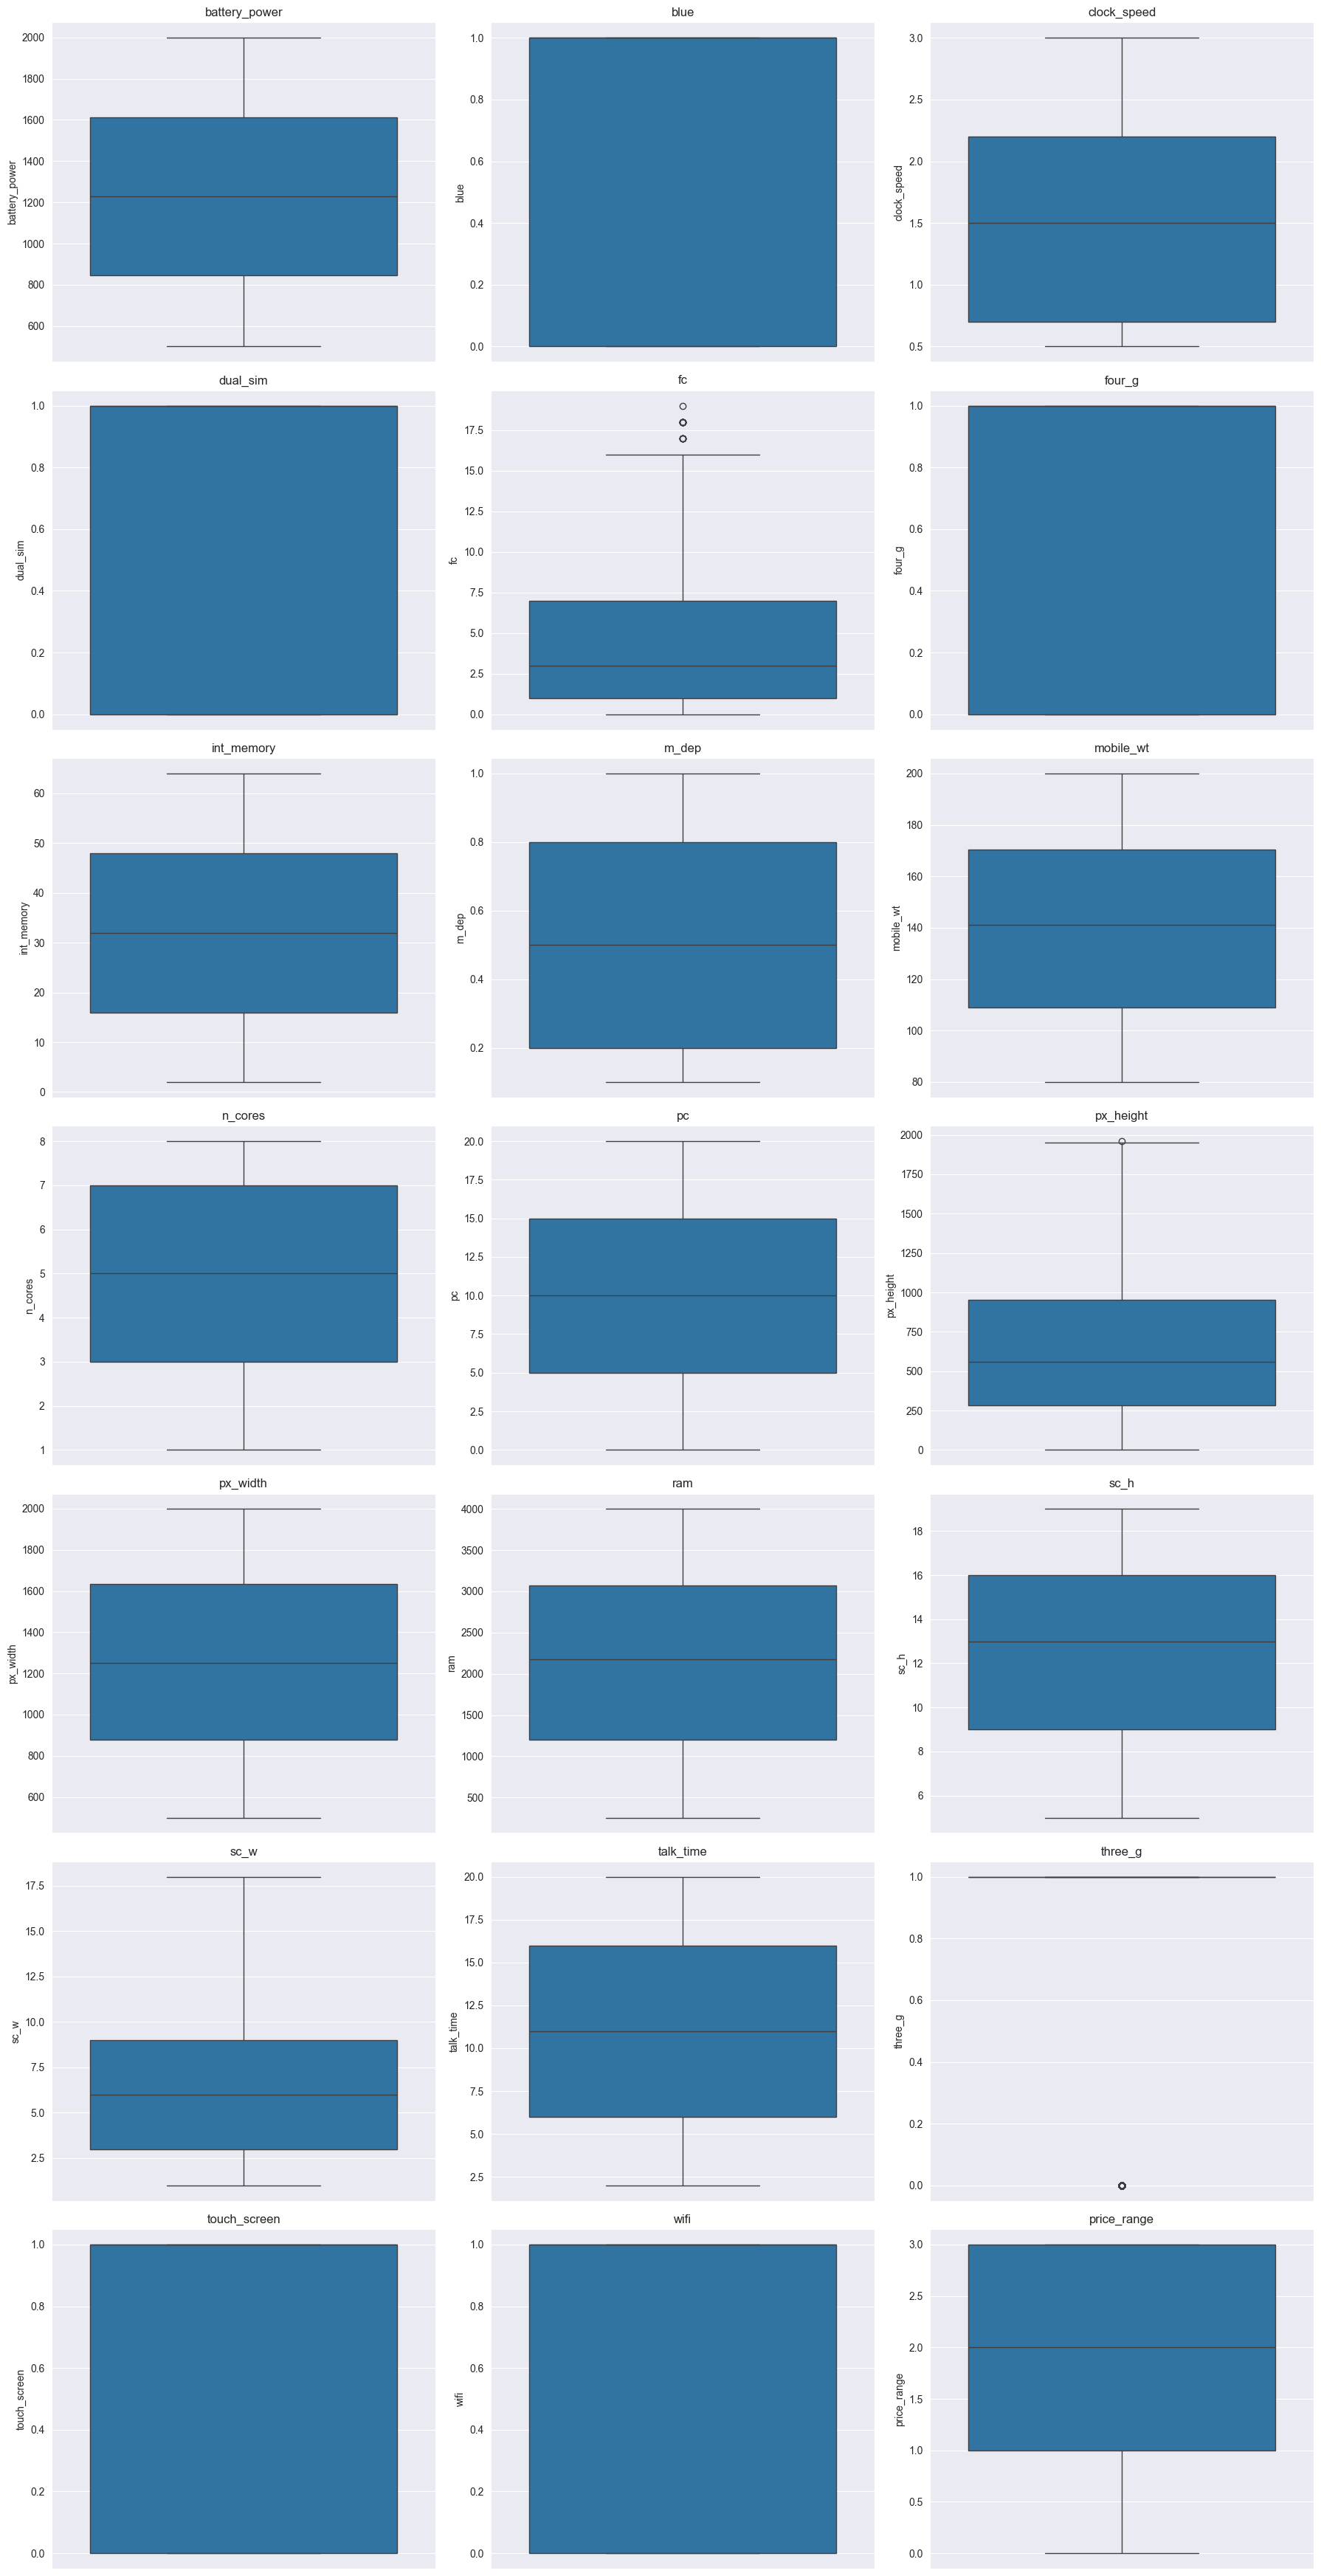

In [64]:
show_boxplot(df)

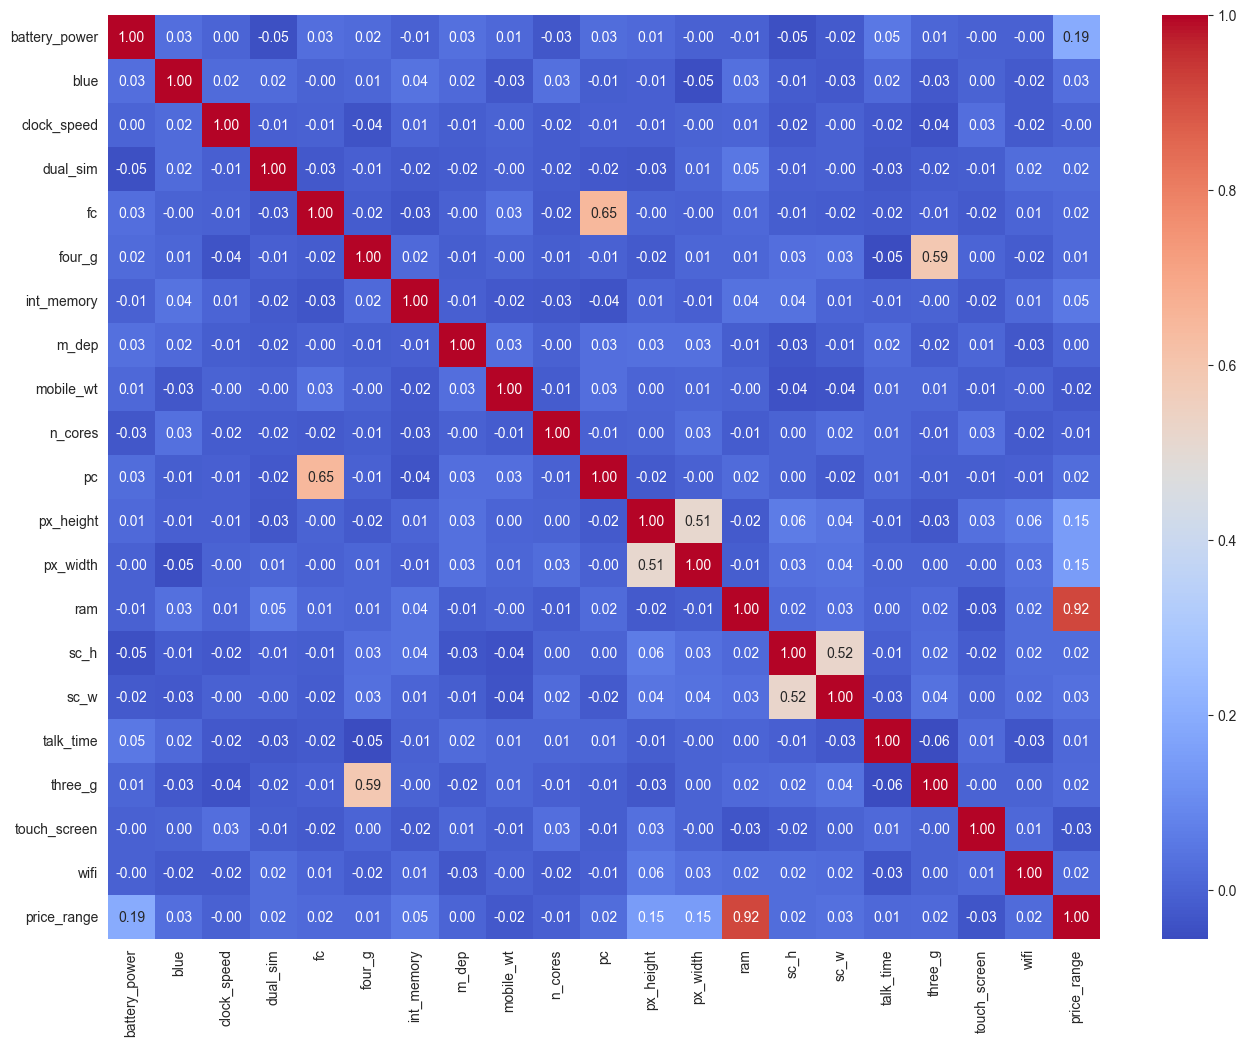

In [76]:
plt.figure(figsize=(16, 12))   # EN ÖNEMLİ KISIM: figsize
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

In [77]:
X= df.drop("price_range", axis=1)
y = df["price_range"]

In [78]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [82]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# ---------------------------------------------------------------
# 📌 METRIC HESAPLAMA FONKSİYONU
# ---------------------------------------------------------------
def calculate_classification_metrics(true, predicted):
    accuracy = accuracy_score(true, predicted)
    precision = precision_score(true, predicted, average='weighted', zero_division=0)
    recall = recall_score(true, predicted, average='weighted', zero_division=0)
    f1 = f1_score(true, predicted, average='weighted', zero_division=0)
    return accuracy, precision, recall, f1


# ---------------------------------------------------------------
# 📌 TÜM MODELLERİ EĞİTEN VE KARŞILAŞTIRMA TABLOSU DÖNDÜREN FONKSİYON
# ---------------------------------------------------------------
def evaluate_all_models(X_train, X_test, y_train, y_test):

    models = {
        "Logistic Regression": LogisticRegression(max_iter=500),
        "Decision Tree": DecisionTreeClassifier(),
        "Random Forest": RandomForestClassifier(),
        "KNN": KNeighborsClassifier(),
        "SVM": SVC(),
        "AdaBoost": AdaBoostClassifier(),
        "GradientBoosting": GradientBoostingClassifier(),
        "XGBClassifier": XGBClassifier(eval_metric="logloss")
    }

    results = []

    for name, model in models.items():
        model.fit(X_train, y_train)

        # Train & Test tahminleri
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # Metrikler
        train_acc, train_prec, train_rec, train_f1 = calculate_classification_metrics(y_train, y_train_pred)
        test_acc, test_prec, test_rec, test_f1 = calculate_classification_metrics(y_test, y_test_pred)

        results.append({
            "Model": name,
            "Train Acc": train_acc,
            "Train Prec": train_prec,
            "Train Rec": train_rec,
            "Train F1": train_f1,
            "Test Acc": test_acc,
            "Test Prec": test_prec,
            "Test Rec": test_rec,
            "Test F1": test_f1
        })

    # DataFrame'e dök
    results_df = pd.DataFrame(results)

    # En iyi modeli test accuracy'e göre sırala
    results_df = results_df.sort_values(by="Test Acc", ascending=False).reset_index(drop=True)

    return results_df


In [84]:
pd.set_option('display.width', 1000)
pd.set_option('display.expand_frame_repr', False)
results_df = evaluate_all_models(X_train, X_test, y_train, y_test)
print(results_df.round(4))

                 Model  Train Acc  Train Prec  Train Rec  Train F1  Test Acc  Test Prec  Test Rec  Test F1
0  Logistic Regression     0.9780      0.9780     0.9780    0.9780    0.9588     0.9588    0.9588   0.9586
1     GradientBoosting     1.0000      1.0000     1.0000    1.0000    0.8956     0.8982    0.8956   0.8959
2        XGBClassifier     1.0000      1.0000     1.0000    1.0000    0.8874     0.8883    0.8874   0.8877
3        Decision Tree     1.0000      1.0000     1.0000    1.0000    0.8489     0.8523    0.8489   0.8500
4                  SVM     0.9876      0.9876     0.9876    0.9876    0.8434     0.8473    0.8434   0.8441
5        Random Forest     1.0000      1.0000     1.0000    1.0000    0.8379     0.8395    0.8379   0.8367
6                  KNN     0.6948      0.7059     0.6948    0.6961    0.4588     0.4954    0.4588   0.4623
7             AdaBoost     0.5134      0.5010     0.5134    0.4779    0.4533     0.4759    0.4533   0.4224


In [85]:
#hyperparameter tuning - XGBClassifier

In [111]:
param_grid =  {
    "max_depth": [3,5,6,7],
    "min_child_weight": [1,2,3,5],
    "gamma": [0.1,0.2,0.3,0.4],
    "subsample": [0.1,0.2,0.3,0.4,0.6],
    "colsample_bytree": [0.1,0.2,0.3,0.4,1]
}

In [112]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(estimator=XGBClassifier(), param_grid=param_grid, n_jobs=-1,cv=5,verbose=1)
grid.fit(X_train, y_train)

Fitting 5 folds for each of 1600 candidates, totalling 8000 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.1, 0.2, ...], 'gamma': [0.1, 0.2, ...], 'max_depth': [3, 5, ...], 'min_child_weight': [1, 2, ...], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'multi:softprob'


In [113]:
grid.best_params_

{'colsample_bytree': 1,
 'gamma': 0.2,
 'max_depth': 6,
 'min_child_weight': 1,
 'subsample': 0.6}

In [114]:
y_pred2 = grid.predict(X_test)
print("accuracy_score",accuracy_score(y_test, y_pred2))

accuracy_score 0.8873626373626373
